# 🖊️ Simple MNIST Handwritten Digit Classification
> **Source:** Codebasics Deep Learning Series  
> **Goal:** Build a Neural Network to classify handwritten digits (0–9) using TensorFlow/Keras.

---

## 1. Project Workflow
Following the **Codebasics** methodology, the project is divided into these key steps:

1. **Load Data** – Import the MNIST dataset (60,000 training samples, 10,000 test samples).
2. **Exploration** – Visualize handwritten digits using `plt.matshow()`.
3. **Preprocessing** – Normalize pixel values to the range **0–1**.
4. **Flattening** – Convert each 2D image ($28 \times 28$) into a 1D vector of **784 pixels**.
5. **Model Building** – Define the neural network architecture (Input, Hidden, Output layers).
6. **Evaluation** – Use a **Confusion Matrix** to analyze misclassifications.

---

## 2. Model Architecture

The "Simple MNIST" model in **Codebasics** typically uses a basic **Artificial Neural Network (ANN)**:

| Layer | Type | Description |
| :--- | :--- | :--- |
| **Input** | `Flatten` | Converts the $28 \times 28$ image into a 784-length vector |
| **Hidden** | `Dense` | (Optional) 100 neurons with `ReLU` activation to learn patterns |
| **Output** | `Dense` | 10 neurons (digits 0–9) with `Softmax` activation |

> ⚠️ Without a hidden layer, the model becomes equivalent to **multiclass logistic regression**.

---

## 3. Key Concepts & Code Snippets

### 🔹 Data Normalization
Improves training stability and helps gradient descent converge faster.

```python
X_train = X_train / 255.0
X_test = X_test / 255.0
```

---

### 🔹 Flattening the Images
Neural networks made of **Dense layers** expect 1D input.

```python
X_train = X_train.reshape(len(X_train), 784)
X_test = X_test.reshape(len(X_test), 784)
```

---

### 🔹 Why Flattening is Needed
A basic ANN cannot understand 2D image structure. Flattening converts each image into a vector so it can be processed by fully connected layers.

However, this removes spatial relationships between pixels — which is why **CNNs perform better on image tasks**.

---

## 4. ANN vs CNN (Concept Preview)

| Model | Input Shape | Keeps Spatial Structure? | MNIST Accuracy |
|------|-------------|---------------------------|----------------|
| Basic ANN (Codebasics) | (784,) | ❌ No | ~97–98% |
| CNN | (28, 28, 1) | ✅ Yes | ~99%+ |

---

## 5. Summary

- The Codebasics model demonstrates the **simplest form of a neural network**
- Images are flattened because **Dense layers require 1D input**
- Adding hidden layers improves performance by learning non-linear patterns
- CNNs are a more advanced architecture designed specifically for image data

---

## I. Import Libraries & modules

In [21]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## II. Define train / test data

In [ ]:
# Return type of load_data() is (train_images, train_labels), (test_images, test_labels)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

Number of training sets:  60000
Number of test sets:  10000
Data exmple:  [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0

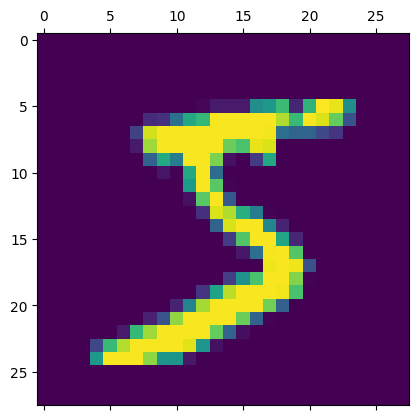

In [4]:
# Get used to dataset
print("Number of training sets: ", len(x_train))
print("Number of test sets: ", len(x_test))

# Digit is stored as 2D array, each number indicates the brightness (0 - 255) of pixels
print("Data exmple: ", x_train[0])

# Visualize the training digit
plt.matshow(x_train[0])

print("Label: ", y_train[0])

In [5]:
# Data Normalization (scale from 0 - 1)
x_train = x_train / 255
x_test = x_test / 255

In [6]:
print("Training array shape: ", x_train.shape)
print("Testing array shape: ", x_test.shape)

Training array shape:  (60000, 28, 28)
Testing array shape:  (10000, 28, 28)


In [7]:
# Flatten 28x28 images into 1D vectors (28 x 28 = 784 pixels) 
# because a basic ANN - Arificial Neural Network (Dense network) only accepts 1D input

x_train_flattened = x_train.reshape(len(x_train), 784)
x_test_flattened = x_test.reshape(len(x_test), 784)

print("Training shape after flattened: ", x_train_flattened.shape)
print("Testing shape after flattened: ", x_test_flattened.shape)
x_train_flattened[0]

Training shape after flattened:  (60000, 784)
Testing shape after flattened:  (10000, 784)


array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

## III. Model Development

In [8]:
# Simple 1 layer Model
model = keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,), activation='softmax')
    # 10 output neurons (1 for each digit from 0 - 9)
    # Each image is flattened to 784-value array
    # Softmax: convert outputs to probabilities of (0 - 9)
])

model.compile(
    optimizer='adam',       # Fast & adaptive optimazer
    loss='sparse_categorical_crossentropy',     # Used as labels are integers (digits)
    metrics=['accuracy'],       # Measure percentage of correct predictions
)

# Train the model
# Epochs are the number of times model scan through the training set
model.fit(x_train_flattened, y_train, epochs=5)

Epoch 1/5


C:\Users\Windows\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 532us/step - accuracy: 0.8768 - loss: 0.4700
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 531us/step - accuracy: 0.9158 - loss: 0.3041
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 537us/step - accuracy: 0.9204 - loss: 0.2837
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 533us/step - accuracy: 0.9237 - loss: 0.2733
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 536us/step - accuracy: 0.9249 - loss: 0.2667


In [10]:
# Evaluate the trained model on test data to measure its performance
# Accuracy shows how many predictions are correct
# Loss indicates how far the predictions are from the true labels
model.evaluate(x_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step - accuracy: 0.9258 - loss: 0.2665


[0.2665388286113739, 0.9258000254631042]

## IV. Predicting test data

In [18]:
y_predict = model.predict(x_test_flattened)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 414us/step


[1.4966304e-04 6.2196929e-04 2.3251001e-02 8.3173887e-04 1.8637150e-04
 3.3766490e-05 9.7447813e-01 4.4529334e-05 3.8687326e-04 1.5872456e-05]
Model prediction:  6


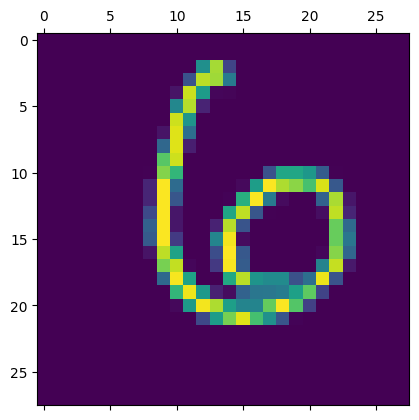

In [19]:
plt.matshow(x_test[100])
print(y_predict[100])       # Return an array of probabilities of 0 - 9
print("Model prediction: ", np.argmax(y_predict[100]))

[2.10232514e-07 9.35257704e-05 1.25145762e-05 1.37228042e-01
 2.08741985e-03 1.21869794e-04 1.30378083e-07 1.50357246e-01
 1.26899779e-03 7.08830118e-01]
Model prediction:  9


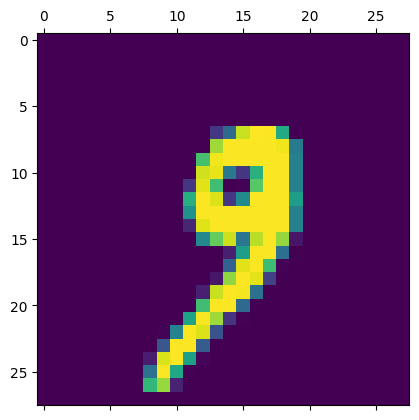

In [20]:
plt.matshow(x_test[1000])
print(y_predict[1000])       # Return an array of probabilities of 0 - 9
print("Model prediction: ", np.argmax(y_predict[1000]))

## V. Visualize efficiency of Model

Text(95.72222222222221, 0.5, 'Truth')

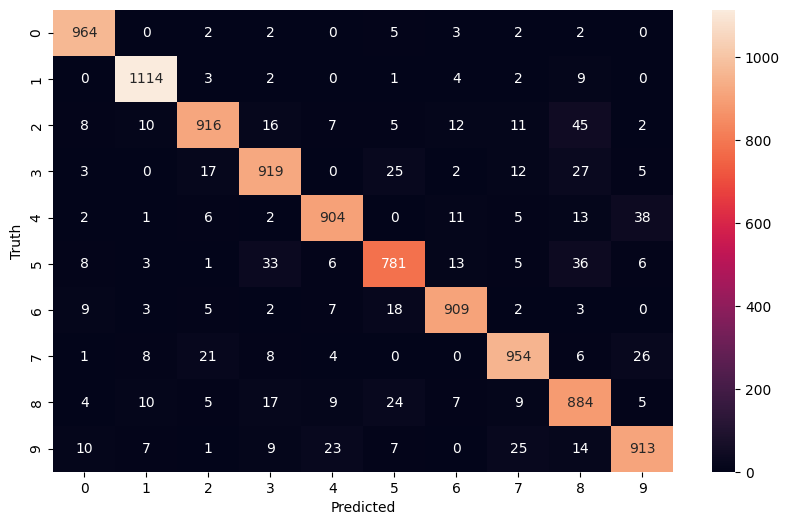

In [22]:
# Get an array of all predicted labels
y_predict_labels = [np.argmax(i) for i in y_predict]

# Create Confusion Matrix
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_predict_labels)

# Create Heatmap to visualize Confusion Matrix
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')


## VI. Enhance the Model

In [32]:
# Add more hidden layer
model = keras.Sequential([
    # Model reshape 2D 28 x 28 to 1D 784
    # 100 neurons: learn 100 different features from the images
    # ReLU activation: allows the model to learn non-linear patterns
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

# Train the model
# No need to use flattened x_train as the model will auto flatten it
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 740us/step - accuracy: 0.9240 - loss: 0.2661
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 746us/step - accuracy: 0.9633 - loss: 0.1251
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 738us/step - accuracy: 0.9739 - loss: 0.0873
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 741us/step - accuracy: 0.9793 - loss: 0.0681
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 755us/step - accuracy: 0.9838 - loss: 0.0549


In [33]:
model.evaluate(x_test, y_test)

# More accuracy & less loss ===> Better performance
# accuracy: 0.9765 - loss: 0.0764       >       accuracy: 0.9258 - loss: 0.2665


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step - accuracy: 0.9766 - loss: 0.0763


[0.07631675153970718, 0.9765999913215637]